# Análisis de Sensibilidad y Comparación con Informe

Este notebook:

1. Carga la instancia base (T30, H100) desde los resultados de Gurobi V13.0.1 Flo-aq
2. Corre los 3 análisis de sensibilidad (equipos, T_max, demanda)
3. Reproduce las tablas y gráficos del informe con los mismos encabezados
4. Compara cada número del tex contra los resultados reales


In [11]:
from main import cargar_datos, construir_modelo
import sys
import os
import copy
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

sys.path.insert(0, os.path.abspath("."))

BASE = os.path.abspath(".")
GUROBI_DIR = os.path.join(BASE, "resultados Gurobi V13.0.1 Flo-aq")
INST_DIR = os.path.join(GUROBI_DIR, "T30_H100", "instancia")
SENS_OUT = os.path.join(GUROBI_DIR, "sensibilidad")
GRAF_OUT = os.path.join(SENS_OUT, "graficos")
os.makedirs(SENS_OUT, exist_ok=True)
os.makedirs(GRAF_OUT, exist_ok=True)

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False
})

## 1. Cargar instancia base (T30, H100)


In [12]:
d_base = cargar_datos(INST_DIR)
print(f"T_max base    : {d_base['T_max']} min")
print(f"H_t base      : {list(d_base['H_t'].values())}")
print(f"Demanda total : {sum(d_base['D_itg'].values())} pacientes-día")
print(
    f"|I|={len(d_base['I'])}  |J|={len(d_base['J'])}  |K|={len(d_base['K'])}")

T_max base    : 30 min
H_t base      : [19, 32, 55, 78, 93, 104, 112]
Demanda total : 16144 pacientes-día
|I|=36  |J|=85  |K|=32


## 2. Funciones de sensibilidad


In [13]:
FACTORES_HT = [0.50, 0.70, 0.85, 1.00, 1.15, 1.30]
VALORES_TMAX = [10, 15, 20, 25, 30, 40]
FACTORES_DEM = [0.80, 0.90, 1.00, 1.10, 1.20, 1.40]


def resolver_instancia(d_mod):
    m, vars_ = construir_modelo(d_mod)
    m.setParam("OutputFlag", 0)
    m.setParam("TimeLimit", 300)
    m.optimize()
    if m.SolCount == 0:
        return None
    z, p, a, s, w = vars_["z"], vars_["p"], vars_["a"], vars_["s"], vars_["w"]
    I, J, T, G, K = d_mod["I"], d_mod["J"], d_mod["T"], d_mod["G"], d_mod["K"]
    centros_dia = {t: sum(1 for j in J if z[j, t].X > 0.5) for t in T}
    equipos_dia = {t: sum(round(p[j, t].X) for j in J) for t in T}
    return {
        "fo":          round(m.ObjVal, 2),
        "gap_pct":     round(m.MIPGap * 100, 4),
        "atend_total": round(sum(a[i, j, t, g].X for i in I for j in J for t in T for g in G)),
        "espera_leve": round(sum(s[i, t, "leve"].X for i in I for t in T)),
        "espera_mod":  round(sum(s[i, t, "moderado"].X for i in I for t in T)),
        "graves_hosp": round(sum(w[i, k, t, "grave"].X for i in I for k in K for t in T)) if w else 0,
        "centros_max": max(centros_dia.values()),
        "equipos_max": max(equipos_dia.values()),
    }


def recalcular_Aij(d):
    d["A_ij"] = {(i, j): 1 if t <= d["T_max"] else 0
                 for (i, j), t in d["T_ij_viaje"].items()}
    return d


def cobertura_stats(d):
    total = len(d["A_ij"])
    activos = sum(d["A_ij"].values())
    return {
        "pares_cubiertos":     activos,
        "pct_cobertura":       round(activos / total * 100, 1) if total else 0,
        "zonas_sin_cobertura": sum(1 for i in d["I"]
                                   if all(d["A_ij"].get((i, j), 0) == 0 for j in d["J"])),
    }


print("Funciones definidas.")

Funciones definidas.


## 3. Análisis 1 — Equipos médicos disponibles (H_t)

> ⚠️ Esta celda tarda varios minutos (6 corridas × ~1 min cada una)


In [14]:
res_equipos = []
for factor in FACTORES_HT:
    print(f"  Factor={factor:.2f} ...", end=" ", flush=True)
    d_mod = copy.deepcopy(d_base)
    d_mod["H_t"] = {t: max(1, round(v * factor))
                    for t, v in d_base["H_t"].items()}
    res = resolver_instancia(d_mod)
    if res:
        res["factor"] = factor
        print(f"FO={res['fo']:,.1f}  Gap={res['gap_pct']:.2f}%")
    else:
        print("INFACTIBLE")
    res_equipos.append(res)
print("\nAnálisis equipos completado.")

  Factor=0.50 ... 

Set parameter OutputFlag to value 1
Set parameter TimeLimit to value 1800
FO=140,260.2  Gap=0.00%
  Factor=0.70 ... Set parameter OutputFlag to value 1
Set parameter TimeLimit to value 1800
FO=112,808.7  Gap=0.00%
  Factor=0.85 ... Set parameter OutputFlag to value 1
Set parameter TimeLimit to value 1800
FO=96,457.2  Gap=0.01%
  Factor=1.00 ... Set parameter OutputFlag to value 1
Set parameter TimeLimit to value 1800
FO=82,857.2  Gap=0.00%
  Factor=1.15 ... Set parameter OutputFlag to value 1
Set parameter TimeLimit to value 1800
FO=71,214.2  Gap=0.00%
  Factor=1.30 ... Set parameter OutputFlag to value 1
Set parameter TimeLimit to value 1800
FO=61,019.2  Gap=0.00%

Análisis equipos completado.


## 4. Análisis 2 — Tiempo máximo de cobertura (T_max)

> ⚠️ Esta celda tarda varios minutos (6 corridas × ~1 min cada una)


In [15]:
res_tmax = []
cob_stats = []
for tmax in VALORES_TMAX:
    print(f"  T_max={tmax} min ...", end=" ", flush=True)
    d_mod = copy.deepcopy(d_base)
    d_mod["T_max"] = tmax
    recalcular_Aij(d_mod)
    cob = cobertura_stats(d_mod)
    cob_stats.append(cob)
    res = resolver_instancia(d_mod)
    if res:
        res["tmax"] = tmax
        print(f"FO={res['fo']:,.1f}  Cob={cob['pct_cobertura']}%")
    else:
        print("INFACTIBLE")
    res_tmax.append(res)
print("\nAnálisis T_max completado.")

  T_max=10 min ... Set parameter OutputFlag to value 1
Set parameter TimeLimit to value 1800
FO=94,547.2  Cob=2.7%
  T_max=15 min ... Set parameter OutputFlag to value 1
Set parameter TimeLimit to value 1800
FO=91,052.7  Cob=3.5%
  T_max=20 min ... Set parameter OutputFlag to value 1
Set parameter TimeLimit to value 1800
FO=88,480.7  Cob=4.3%
  T_max=25 min ... Set parameter OutputFlag to value 1
Set parameter TimeLimit to value 1800
FO=85,517.7  Cob=5.1%
  T_max=30 min ... Set parameter OutputFlag to value 1
Set parameter TimeLimit to value 1800
FO=82,857.2  Cob=6.0%
  T_max=40 min ... Set parameter OutputFlag to value 1
Set parameter TimeLimit to value 1800
FO=80,608.7  Cob=8.5%

Análisis T_max completado.


## 5. Análisis 3 — Demanda de pacientes (D_itg)

> ⚠️ Esta celda tarda varios minutos (6 corridas × ~1 min cada una)


In [16]:
res_demanda = []
for factor in FACTORES_DEM:
    print(f"  Factor={factor:.2f} ...", end=" ", flush=True)
    d_mod = copy.deepcopy(d_base)
    d_mod["D_itg"] = {k: max(0, round(v * factor))
                      for k, v in d_base["D_itg"].items()}
    d_mod["D_ig_max"] = {k: max(0, round(v * factor))
                         for k, v in d_base["D_ig_max"].items()}
    res = resolver_instancia(d_mod)
    if res:
        res["factor"] = factor
        print(f"FO={res['fo']:,.1f}  Gap={res['gap_pct']:.2f}%")
    else:
        print("INFACTIBLE")
    res_demanda.append(res)
print("\nAnálisis demanda completado.")

  Factor=0.80 ... Set parameter OutputFlag to value 1
Set parameter TimeLimit to value 1800
FO=53,658.9  Gap=0.01%
  Factor=0.90 ... Set parameter OutputFlag to value 1
Set parameter TimeLimit to value 1800
FO=67,610.5  Gap=0.01%
  Factor=1.00 ... Set parameter OutputFlag to value 1
Set parameter TimeLimit to value 1800
FO=82,857.2  Gap=0.00%
  Factor=1.10 ... Set parameter OutputFlag to value 1
Set parameter TimeLimit to value 1800
FO=98,896.2  Gap=0.01%
  Factor=1.20 ... Set parameter OutputFlag to value 1
Set parameter TimeLimit to value 1800
FO=116,077.6  Gap=0.01%
  Factor=1.40 ... Set parameter OutputFlag to value 1
Set parameter TimeLimit to value 1800
FO=152,704.9  Gap=0.02%

Análisis demanda completado.


---

## 6. Tabla A1 — Sensibilidad equipos (Anexo D)

Mismos encabezados que en el informe.


In [17]:
filas_eq = []
escenarios_eq = ["$H_t\\cdot 0{,}5$", "$H_t\\cdot 0{,}7$", "$H_t\\cdot 0{,}85$",
                 "$H_t$", "$H_t\\cdot 1{,}15$", "$H_t\\cdot 1{,}3$"]
factores_label = ["50% estándar", "70% estándar", "85% estándar",
                  "estándar", "115% estándar", "130% estándar"]
for i, r in enumerate(res_equipos):
    if r:
        filas_eq.append({
            "escenario":   escenarios_eq[i],
            "factor":      r["factor"],
            "fo":          round(r["fo"]),
            "gap_pct":     r["gap_pct"],
            "atend_total": r["atend_total"],
            "espera_leve": r["espera_leve"],
            "espera_mod":  r["espera_mod"],
            "graves_hosp": r["graves_hosp"],
            "centros_max": r["centros_max"],
            "equipos_max": r["equipos_max"],
        })
    else:
        filas_eq.append(
            {"escenario": escenarios_eq[i], "factor": FACTORES_HT[i], "fo": None})

df_eq = pd.DataFrame(filas_eq)

# Guardar CSV
csv_path = os.path.join(SENS_OUT, "sensibilidad_equipos.csv")
df_eq.to_csv(csv_path, index=False, encoding="utf-8")
print(f"Guardado: {csv_path}")

# Mostrar con headers del informe
display(df_eq.rename(columns={
    "escenario": "Escenario", "factor": "Factor", "fo": "FO",
    "atend_total": "Atenciones", "espera_leve": "Espera leve",
    "espera_mod": "Espera moderada", "centros_max": "Centros máximos",
    "equipos_max": "Equipos máximos"
}).drop(columns=["gap_pct", "graves_hosp"], errors="ignore"))

Guardado: c:\Users\flore\OneDrive\Escritorio\2026-1\Opti\Proyecto\resultados Gurobi V13.0.1 Flo-aq\sensibilidad\sensibilidad_equipos.csv


,Escenario,Factor,FO,Atenciones,Espera leve,Espera moderada,Centros máximos,Equipos máximos
0,"$H_t\cdot 0{,}5$",0.50,140260,2964,51175,8881,9,56
1,"$H_t\cdot 0{,}7$",0.70,112809,5229,48714,6382,14,78
2,"$H_t\cdot 0{,}85$",0.85,96457,7004,45672,5051,19,95
3,$H_t$,1.00,82857,7876,43302,3928,19,112
4,"$H_t\cdot 1{,}15$",1.15,71214,10784,37169,3377,19,129
5,"$H_t\cdot 1{,}3$",1.30,61019,12816,32234,2851,18,146


## 7. Tabla A2 — Sensibilidad T_max (Anexo D)


In [18]:
filas_tm = []
for i, (r, cob) in enumerate(zip(res_tmax, cob_stats)):
    if r:
        filas_tm.append({
            "escenario":       f"tmax_t{VALORES_TMAX[i]}",
            "tmax":            VALORES_TMAX[i],
            "fo":              round(r["fo"]),
            "gap_pct":         r["gap_pct"],
            "pares_cubiertos": cob["pares_cubiertos"],
            "pct_cobertura":   cob["pct_cobertura"],
            "zonas_sin_cob":   cob["zonas_sin_cobertura"],
            "atend_total":     r["atend_total"],
            "espera_leve":     r["espera_leve"],
            "espera_mod":      r["espera_mod"],
            "graves_hosp":     r["graves_hosp"],
            "centros_max":     r["centros_max"],
            "equipos_max":     r["equipos_max"],
        })
    else:
        filas_tm.append(
            {"escenario": f"tmax_t{VALORES_TMAX[i]}", "tmax": VALORES_TMAX[i], "fo": None})

df_tm = pd.DataFrame(filas_tm)

# Guardar CSV
csv_path = os.path.join(SENS_OUT, "sensibilidad_tmax.csv")
df_tm.to_csv(csv_path, index=False, encoding="utf-8")
print(f"Guardado: {csv_path}")

# Mostrar con headers del informe
display(df_tm.rename(columns={
    "escenario": "Escenario", "tmax": "T_max [min]",
    "pares_cubiertos": "Pares cubiertos", "pct_cobertura": "Cobertura",
    "zonas_sin_cob": "Zonas sin PMA", "fo": "FO", "atend_total": "Atenciones",
    "espera_leve": "Espera leve", "espera_mod": "Espera moderada"
}).drop(columns=["gap_pct", "graves_hosp", "centros_max", "equipos_max"], errors="ignore"))

Guardado: c:\Users\flore\OneDrive\Escritorio\2026-1\Opti\Proyecto\resultados Gurobi V13.0.1 Flo-aq\sensibilidad\sensibilidad_tmax.csv


,Escenario,T_max [min],FO,Pares cubiertos,Cobertura,Zonas sin PMA,Atenciones,Espera leve,Espera moderada
0,tmax_t10,10,94547,83,2.7,2,8514,40282,5399
1,tmax_t15,15,91053,106,3.5,1,8753,40537,5024
2,tmax_t20,20,88481,131,4.3,0,8413,41716,4649
3,tmax_t25,25,85518,156,5.1,0,8202,42392,4285
4,tmax_t30,30,82857,184,6.0,0,7876,43302,3928
5,tmax_t40,40,80609,259,8.5,0,8496,42764,3757


## 8. Tabla A3 — Sensibilidad demanda (Anexo D)


In [19]:
filas_dem = []
for i, r in enumerate(res_demanda):
    if r:
        filas_dem.append({
            "escenario":   f"demanda_f{FACTORES_DEM[i]:.2f}",
            "factor":      r["factor"],
            "fo":          round(r["fo"]),
            "gap_pct":     r["gap_pct"],
            "atend_total": r["atend_total"],
            "espera_leve": r["espera_leve"],
            "espera_mod":  r["espera_mod"],
            "graves_hosp": r["graves_hosp"],
            "centros_max": r["centros_max"],
            "equipos_max": r["equipos_max"],
        })
    else:
        filas_dem.append({"escenario": f"demanda_f{FACTORES_DEM[i]:.2f}",
                          "factor": FACTORES_DEM[i], "fo": None})

df_dem = pd.DataFrame(filas_dem)

# Guardar CSV
csv_path = os.path.join(SENS_OUT, "sensibilidad_demanda.csv")
df_dem.to_csv(csv_path, index=False, encoding="utf-8")
print(f"Guardado: {csv_path}")

# Mostrar con headers del informe
escenarios_dem_lbl = ["$D_{i,t,g}\\cdot 0{,}8$", "$D_{i,t,g}\\cdot 0{,}9$",
                      "$D_{i,t,g}$", "$D_{i,t,g}\\cdot 1{,}1$",
                      "$D_{i,t,g}\\cdot 1{,}2$", "$D_{i,t,g}\\cdot 1{,}4$"]
factores_dem_lbl = ["80%", "90%", "estándar", "110%", "120%", "140%"]
df_dem_show = df_dem.copy()
df_dem_show["Escenario"] = [escenarios_dem_lbl[i] for i in range(len(df_dem))]
df_dem_show["Factor demanda"] = [factores_dem_lbl[i]
                                 for i in range(len(df_dem))]
display(df_dem_show.rename(columns={
    "fo": "FO", "atend_total": "Atenciones", "espera_leve": "Espera leve",
    "espera_mod": "Espera moderada", "graves_hosp": "Graves hospital",
    "centros_max": "Centros máximos"
})[["Escenario", "Factor demanda", "FO", "Atenciones",
    "Espera leve", "Espera moderada", "Graves hospital", "Centros máximos"]])

Guardado: c:\Users\flore\OneDrive\Escritorio\2026-1\Opti\Proyecto\resultados Gurobi V13.0.1 Flo-aq\sensibilidad\sensibilidad_demanda.csv


,Escenario,Factor demanda,FO,Atenciones,Espera leve,Espera moderada,Graves hospital,Centros máximos
0,"$D_{i,t,g}\cdot 0{,}8$",80%,53659,9168,28032,2540,1310,19
1,"$D_{i,t,g}\cdot 0{,}9$",90%,67611,8995,34918,3243,1481,18
2,"$D_{i,t,g}$",estándar,82857,7876,43302,3928,1614,19
3,"$D_{i,t,g}\cdot 1{,}1$",110%,98896,7860,49777,4883,1747,18
4,"$D_{i,t,g}\cdot 1{,}2$",120%,116078,7458,56442,5931,1918,19
5,"$D_{i,t,g}\cdot 1{,}4$",140%,152705,7497,68269,8404,2249,18


---

## 9. Gráfico — Sensibilidad equipos


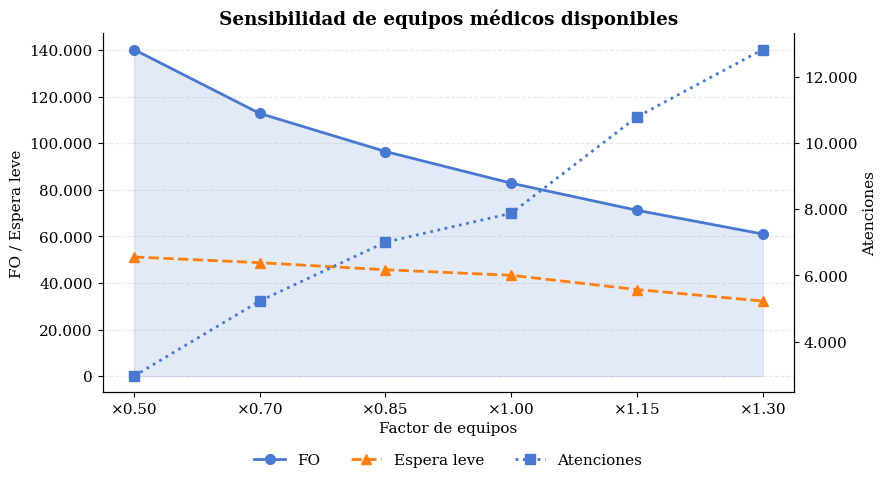

In [33]:
factores_eq_lbl = ["×0.50", "×0.70", "×0.85", "×1.00", "×1.15", "×1.30"]
fos_eq = [r["fo"] for r in res_equipos if r]
espl_eq = [r["espera_leve"] for r in res_equipos if r]
atend_eq = [r["atend_total"] for r in res_equipos if r]
x_eq = list(range(len(fos_eq)))

fig, ax1 = plt.subplots(figsize=(9, 5))
plt.rcParams.update({"axes.spines.right": True})

ax1.fill_between(x_eq, fos_eq, alpha=0.15, color="#4878CF")
l1, = ax1.plot(x_eq, fos_eq,  marker="o", lw=2,
               ms=7, color="#4878CF", label="FO")
l2, = ax1.plot(x_eq, espl_eq, marker="^", lw=2, ms=7,
               color="#ff7f0e", linestyle="--", label="Espera leve")
ax1.set_xlabel("Factor de equipos")
ax1.set_ylabel("FO / Espera leve")
ax1.set_xticks(x_eq)
ax1.set_xticklabels(factores_eq_lbl)
ax1.yaxis.set_major_locator(mticker.MultipleLocator(20000))
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"{int(x):,}".replace(",", ".")))
ax1.grid(axis="y", linestyle="--", alpha=0.3)

ax2 = ax1.twinx()
l3, = ax2.plot(x_eq, atend_eq, marker="s", lw=2, ms=7,
               color="#4878CF", linestyle=":", label="Atenciones")
ax2.set_ylabel("Atenciones")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"{int(x):,}".replace(",", ".")))

plt.title("Sensibilidad de equipos médicos disponibles", fontweight="bold")
lines = [l1, l2, l3]
ax1.legend(lines, [l.get_label() for l in lines],
           loc="upper center", bbox_to_anchor=(0.5, -0.13), ncol=3, frameon=False)
fig.tight_layout()
fig.savefig(os.path.join(GRAF_OUT, "grafico_equipos.png"),
            dpi=150, bbox_inches="tight")
plt.show()

## 10. Gráfico — Sensibilidad T_max


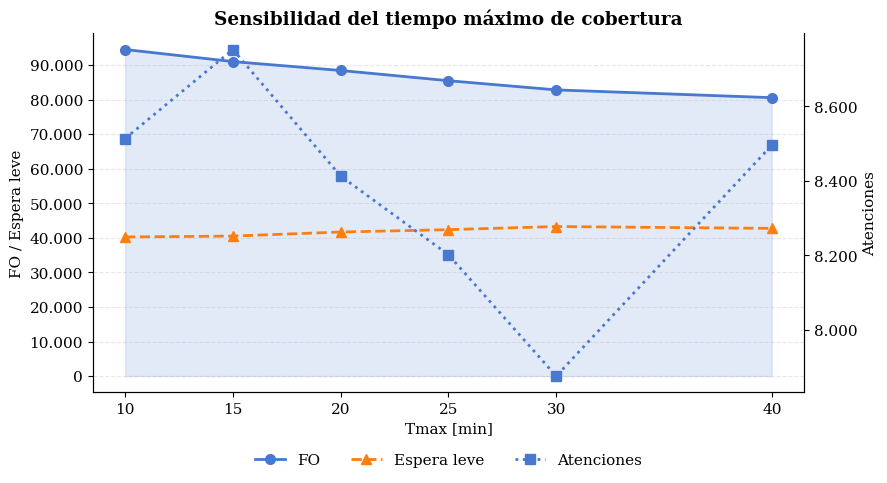

In [36]:
fos_tm = [r["fo"] for r in res_tmax if r]
espl_tm = [r["espera_leve"] for r in res_tmax if r]
atend_tm = [r["atend_total"] for r in res_tmax if r]
tmaxs = [r["tmax"] for r in res_tmax if r]

fig, ax1 = plt.subplots(figsize=(9, 5))

ax1.fill_between(tmaxs, fos_tm, alpha=0.15, color="#4878CF")
l1, = ax1.plot(tmaxs, fos_tm,  marker="o", lw=2,
               ms=7, color="#4878CF", label="FO")
l2, = ax1.plot(tmaxs, espl_tm, marker="^", lw=2, ms=7,
               color="#ff7f0e", linestyle="--", label="Espera leve")
ax1.set_xlabel("Tmax [min]")
ax1.set_ylabel("FO / Espera leve")
ax1.set_xticks(tmaxs)
ax1.yaxis.set_major_locator(mticker.MultipleLocator(10000))
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"{int(x):,}".replace(",", ".")))
ax1.grid(axis="y", linestyle="--", alpha=0.3)

ax2 = ax1.twinx()
l3, = ax2.plot(tmaxs, atend_tm, marker="s", lw=2, ms=7,
               color="#4878CF", linestyle=":", label="Atenciones")
ax2.set_ylabel("Atenciones")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"{int(x):,}".replace(",", ".")))

plt.title("Sensibilidad del tiempo máximo de cobertura", fontweight="bold")
lines = [l1, l2, l3]
ax1.legend(lines, [l.get_label() for l in lines],
           loc="upper center", bbox_to_anchor=(0.5, -0.13), ncol=3, frameon=False)
fig.tight_layout()
fig.savefig(os.path.join(GRAF_OUT, "grafico_tmax.png"),
            dpi=150, bbox_inches="tight")
plt.show()

## 11. Gráfico — Sensibilidad demanda


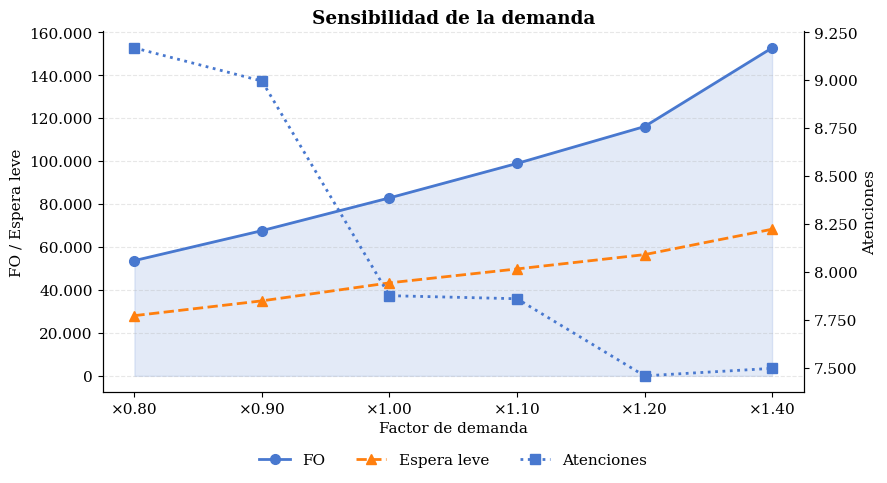

In [38]:
factores_dem_lbl = ["×0.80", "×0.90", "×1.00", "×1.10", "×1.20", "×1.40"]
fos_dem = [r["fo"] for r in res_demanda if r]
espl_dem = [r["espera_leve"] for r in res_demanda if r]
atend_dem = [r["atend_total"] for r in res_demanda if r]
x_dem = list(range(len(fos_dem)))

fig, ax1 = plt.subplots(figsize=(9, 5))

ax1.fill_between(x_dem, fos_dem, alpha=0.15, color="#4878CF")
l1, = ax1.plot(x_dem, fos_dem,  marker="o", lw=2,
               ms=7, color="#4878CF", label="FO")
l2, = ax1.plot(x_dem, espl_dem, marker="^", lw=2, ms=7,
               color="#ff7f0e", linestyle="--", label="Espera leve")
ax1.set_xlabel("Factor de demanda")
ax1.set_ylabel("FO / Espera leve")
ax1.set_xticks(x_dem)
ax1.set_xticklabels(factores_dem_lbl)
ax1.yaxis.set_major_locator(mticker.MultipleLocator(20000))
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"{int(x):,}".replace(",", ".")))
ax1.grid(axis="y", linestyle="--", alpha=0.3)

ax2 = ax1.twinx()
l3, = ax2.plot(x_dem, atend_dem, marker="s", lw=2, ms=7,
               color="#4878CF", linestyle=":", label="Atenciones")
ax2.set_ylabel("Atenciones")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"{int(x):,}".replace(",", ".")))

plt.title("Sensibilidad de la demanda", fontweight="bold")
lines = [l1, l2, l3]
ax1.legend(lines, [l.get_label() for l in lines],
           loc="upper center", bbox_to_anchor=(0.5, -0.13), ncol=3, frameon=False)
fig.tight_layout()
fig.savefig(os.path.join(GRAF_OUT, "grafico_demanda.png"),
            dpi=150, bbox_inches="tight")
plt.show()

---

## 12. Tabla: Resumen diario estándar (Anexo C — tab:estandar-t30h100)


In [23]:
csv_std = os.path.join(GUROBI_DIR, "T30_H100",
                       "resultados", "resultado_resumen_dia.csv")
df_std = pd.read_csv(csv_std)
df_std_tabla = df_std.rename(columns={
    "t":                   "Día",
    "centros_activos":     "Centros",
    "equipos_totales":     "Equipos",
    "pacientes_atendidos": "Atend.",
    "espera_leve":         "Esp. leve",
    "espera_moderado":     "Esp. mod.",
    "graves_hospital":     "Grav. hosp.",
})[["Día", "Centros", "Equipos", "Atend.", "Esp. leve", "Esp. mod.", "Grav. hosp."]]
display(df_std_tabla)

,Día,Centros,Equipos,Atend.,Esp. leve,Esp. mod.,Grav. hosp.
0,1,3,19,228,2688,714,403
1,2,7,32,384,4839,1088,321
2,3,9,55,660,6451,998,244
3,4,10,78,963,7697,535,196
4,5,19,93,1601,7804,281,165
5,6,18,104,2051,7305,176,161
6,7,18,112,1989,6518,136,124


## 13. Tabla: Resumen diario optimizado (Anexo C — tab:optimizado-t30h150)


In [24]:
csv_opt = os.path.join(GUROBI_DIR, "T30_H150",
                       "resultados", "resultado_resumen_dia.csv")
df_opt = pd.read_csv(csv_opt)
df_opt_tabla = df_opt.rename(columns={
    "t":                   "Día",
    "centros_activos":     "Centros",
    "equipos_totales":     "Equipos",
    "pacientes_atendidos": "Atend.",
    "espera_leve":         "Esp. leve",
    "espera_moderado":     "Esp. mod.",
    "graves_hospital":     "Grav. hosp.",
})[["Día", "Centros", "Equipos", "Atend.", "Esp. leve", "Esp. mod.", "Grav. hosp."]]
display(df_opt_tabla)

,Día,Centros,Equipos,Atend.,Esp. leve,Esp. mod.,Grav. hosp.
0,1,4,28,336,2688,606,403
1,2,8,48,576,4839,788,321
2,3,14,82,1098,6254,456,244
3,4,21,117,2164,6068,225,196
4,5,26,139,3056,4554,137,165
5,6,24,156,3552,2517,69,161
6,7,22,168,3710,22,15,124


## 14. Tabla: Comparación de escenarios (Anexo C — tab:comparacion-escenarios)


In [25]:
import csv as _csv


def leer_resumen_txt(carpeta):
    path = os.path.join(GUROBI_DIR, carpeta, "resultados", "resumen.txt")
    fo, gap, tiempo = None, None, None
    with open(path, encoding="utf-8") as f:
        for line in f:
            if "Funcion objetivo" in line:
                fo = float(line.split(":")[1].strip())
            if "MIP Gap" in line:
                gap = line.split(":")[1].strip()
            if "Tiempo de computo" in line:
                tiempo = line.split(":")[1].strip()
    return fo, gap, tiempo


# Demanda total leve y moderado (para calcular tasas)
dem_leve = sum(v for (i, t, g), v in d_base["D_itg"].items() if g == "leve")
dem_mod = sum(v for (i, t, g), v in d_base["D_itg"].items() if g == "moderado")

# Base sin PMAs
fo_base = 231185  # analítico (suma acumulada sin atención)

# Estándar
fo_std, _, _ = leer_resumen_txt("T30_H100")
esp_leve_std_d7 = int(df_std[df_std["t"] == 7]["espera_leve"].values[0])
esp_mod_std_d7 = int(df_std[df_std["t"] == 7]["espera_moderado"].values[0])
peak_std = int(df_std["centros_activos"].max())
tasa_leve_std = round((dem_leve - esp_leve_std_d7) / dem_leve * 100, 1)
tasa_mod_std = round((dem_mod - esp_mod_std_d7) / dem_mod * 100, 1)

# Optimizado
fo_opt, _, _ = leer_resumen_txt("T30_H150")
esp_leve_opt_d7 = int(df_opt[df_opt["t"] == 7]["espera_leve"].values[0])
esp_mod_opt_d7 = int(df_opt[df_opt["t"] == 7]["espera_moderado"].values[0])
peak_opt = int(df_opt["centros_activos"].max())
tasa_leve_opt = round((dem_leve - esp_leve_opt_d7) / dem_leve * 100, 1)
tasa_mod_opt = round((dem_mod - esp_mod_opt_d7) / dem_mod * 100, 1)

df_comp = pd.DataFrame([
    {"Escenario": "Sin PMAs (base)",   "FO": fo_base, "Centros peak": 0,        "Tasa leve": "0%",
     "Tasa mod.": "0%",               "Tasa grave": "100%"},
    {"Escenario": "Triaje estándar",   "FO": round(
        fo_std),  "Centros peak": peak_std, "Tasa leve": f"{tasa_leve_std}%", "Tasa mod.": f"{tasa_mod_std}%",  "Tasa grave": "100%"},
    {"Escenario": "Triaje optimizado", "FO": round(
        fo_opt),  "Centros peak": peak_opt, "Tasa leve": f"{tasa_leve_opt}%", "Tasa mod.": f"{tasa_mod_opt}%",  "Tasa grave": "100%"},
])
display(df_comp)

,Escenario,FO,Centros peak,Tasa leve,Tasa mod.,Tasa grave
0,Sin PMAs (base),231185,0,0%,0%,100%
1,Triaje estándar,82857,19,39.4%,96.4%,100%
2,Triaje optimizado,50178,26,99.8%,99.6%,100%
